# Assignment 1 - Concrete Strength

## 1️ Frame the problem

This step ensures a clear objective, defines the problem selects appropriate evaluation metrics, and verifies key assumptions about the data.

### **1️.1 Business Objective**
The goal is to predict **concrete compressive strength (MPa)** based on material composition. Accurate predictions can reduce reliance on costly physical testing and improve construction planning.

### **1.2 Problem Framing**
- This is a **supervised regression problem** where the goal is to predict a continuous numerical value (MPa).
- Data will be split into **training and test sets**, ensuring proper generalization.
- A mix of **linear and non-linear regression models** will be tested.


### **1.3 Selecting a Performance Measure**
Since this is a regression problem, the following metrics will be used:

- **Mean Squared Error (MSE):**
  $$
  MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
  $$
  Measures the average squared difference between actual and predicted values. Lower values indicate better performance.

- **Root Mean Squared Error (RMSE):**
  $$
  RMSE = \sqrt{MSE}
  $$
  The square root of MSE, making it easier to interpret.

- **R² Score:**
  $$
  R^2 = 1 - \frac{\sum (y_{\text{true}} - y_{\text{pred}})^2}{\sum (y_{\text{true}} - \bar{y})^2}
  $$
    where: 

    $$
    y_{\mathrm{true}} = \text{Actual concrete strength values}
    $$

    $$
    y_{\mathrm{pred}} = \text{Predicted concrete strength values}
    $$

    $$
    \bar{y} = \text{Mean of actual values}
    $$
    Indicates how well the model explains variance in the data. A value closer to **1.0** is ideal.

### **1.4 Checking Assumptions**
Before training models, key assumptions are verified:

- **Feature Relevance:** Each variable should contribute useful information for predicting strength.
- **No Missing Values:** The dataset is complete, so imputation is not required.
- **Reasonable Distribution:** Outliers in features like **Superplasticizer and Age** may need handling, but extreme values appear valid.

By confirming these assumptions, the dataset is deemed suitable for training machine learning models.

## 2️ Get the Data

The dataset is loaded, inspected, and prepared for modeling.

### **2.1️ Importing Necessary Libraries**
Relevant libraries are imported for data handling, visualization, and preprocessing.


### Importing relevant Python libraries : 

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set visualization style
sns.set_style("whitegrid")

### **2️.2 Load the Dataset**
- **Size**: 1030 rows, 8 features, 1 target variable.
- **Features**:
  - `Cement`, `Blast Furnace Slag`, `Fly Ash`, `Water`, `Superplasticizer`, `Coarse Aggregate`, `Fine Aggregate`, `Age`
  - **Target**: `Strength` (MPa) – Concrete compressive strength.

In [2]:
# Load dataset
file_path = "dataset/concrete_data.csv"  
df = pd.read_csv(file_path)

# Display first few rows
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


### **2.3️ Dataset Overview**
A summary of the dataset structure, including feature names, data types.


In [3]:
print("Dataset Overview:")
df.info()

# Display summary statistics
df.describe()

Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### **2.4️ Checking Data Quality**
Before proceeding, the dataset is checked for **missing values** and **duplicate entries**.


In [4]:
# Check for missing values
missing_values = df.isnull().sum().sum()
if missing_values > 0:
    print(f"Missing values detected: {missing_values}")
else:
    print("No missing values detected.")

# Check for duplicate rows
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Duplicate rows detected: {duplicates}")
else:
    print("No duplicate rows detected.")


No missing values detected.
Duplicate rows detected: 25


### **2.5 Splitting the Data**
To prevent **data snooping**, the dataset is split into:
- **80% Training Data** – Used to train machine learning models.
- **20% Test Data** – Kept separate for final model evaluation.
The data is also stratified to ensure the similar distributions in both **80% Training Data** and **20% Test Data**


In [5]:
X = df[['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 
        'Coarse Aggregate', 'Fine Aggregate', 'Age']]
y = df['Strength']

# Stratified split based on the strength variable using quantile binning
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, q=5, duplicates='drop')
)

## 3️ Explore the data

This step explores the dataset to understand its structure, distributions, and relationships. The following aspects are analyzed:
- **Feature distributions**
- **Correlations between variables**
- **Outlier detection**

### **3.1️ Feature Distributions**
Histograms and boxplots reveal feature distributions and potential outliers.


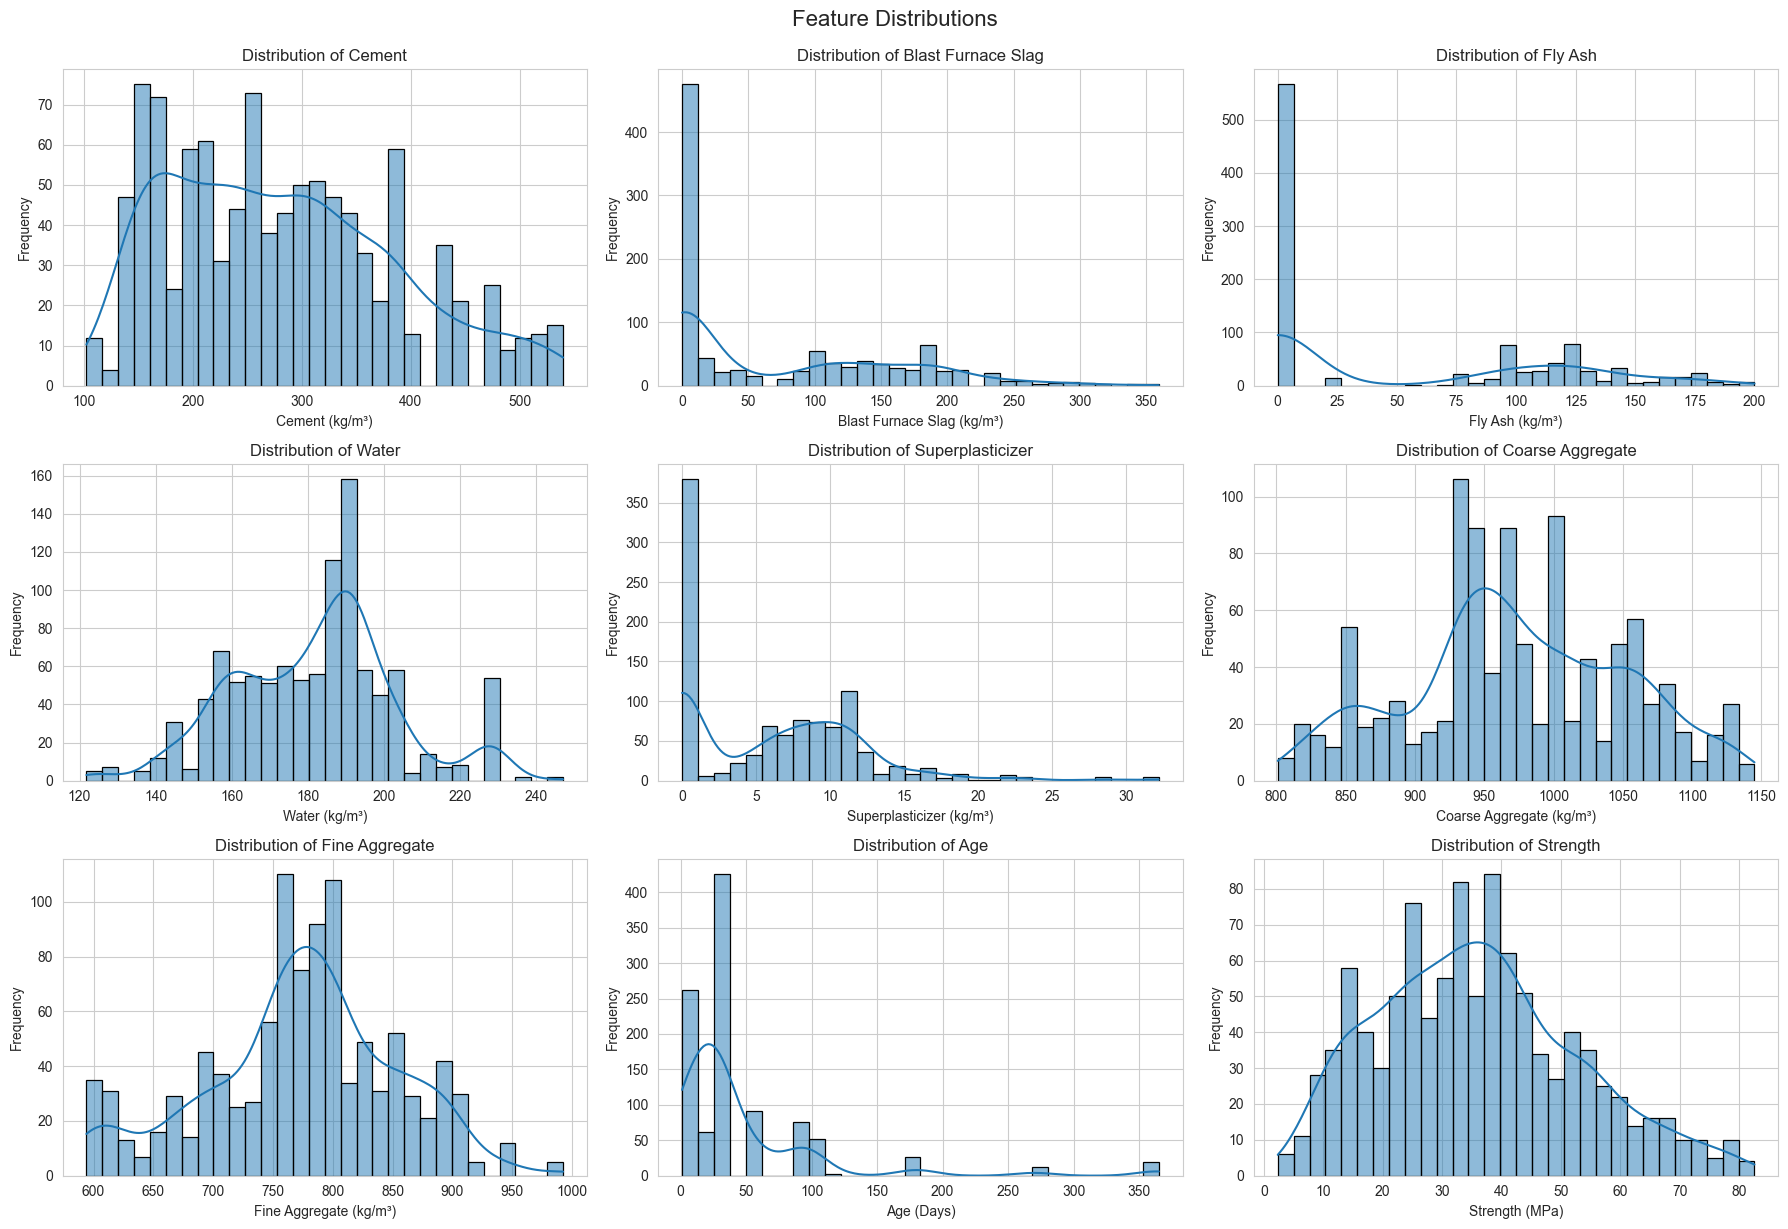

In [6]:
# Define feature names with units
feature_units = {
    "Cement": "kg/m³",
    "Blast Furnace Slag": "kg/m³",
    "Fly Ash": "kg/m³",
    "Water": "kg/m³",
    "Superplasticizer": "kg/m³",
    "Coarse Aggregate": "kg/m³",
    "Fine Aggregate": "kg/m³",
    "Age": "Days",
    "Strength": "MPa"
}

# Plot histograms with proper labels
fig, axes = plt.subplots(3, 3, figsize=(18, 12))  # Create 3x3 grid layout

for ax, col in zip(axes.flatten(), df.columns):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, edgecolor="black")
    ax.set_xlabel(f"{col} ({feature_units.get(col, '')})")  # Add units
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()  # Adjust layout to prevent overlap
plt.suptitle("Feature Distributions", fontsize=16, y=1.02)  # Move title up
plt.show()


/var/folders/yh/k881ccjj4qjb55qnwn5y8l4c0000gn/T/ipykernel_62156/1101406881.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f"{col} ({feature_units.get(col, '')})" for col in df.columns])


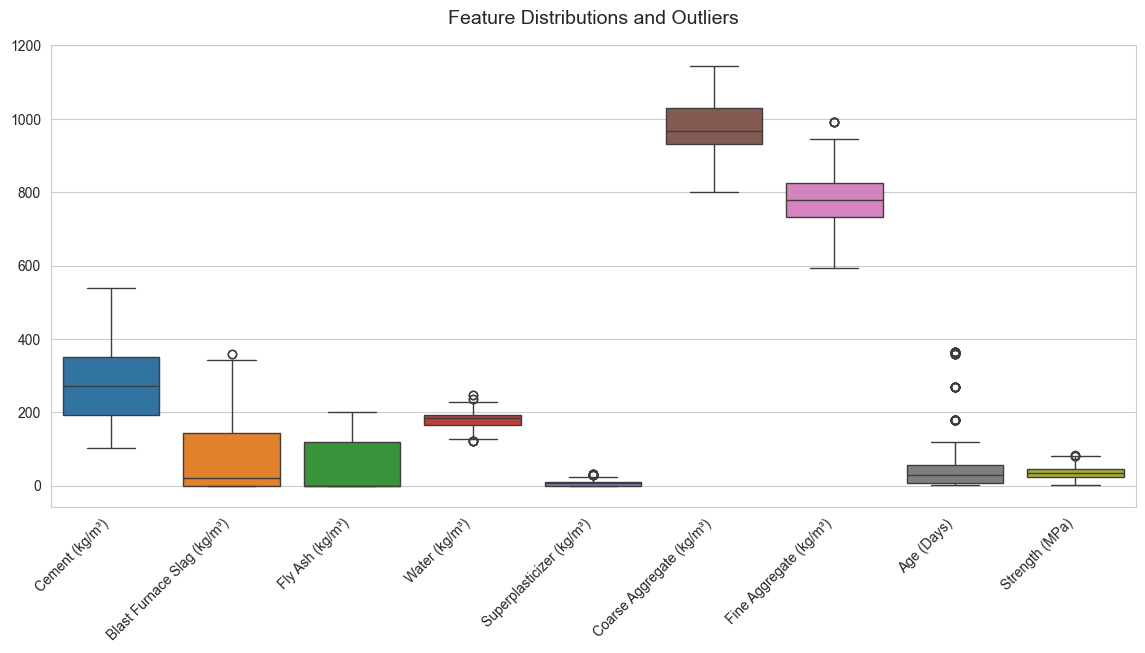

In [7]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df)
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.title("Feature Distributions and Outliers", fontsize=14, pad=15)

# Add feature names with units
ax = plt.gca()
ax.set_xticklabels([f"{col} ({feature_units.get(col, '')})" for col in df.columns])

plt.show()


### **3.2️ Correlation Analysis**
A correlation heatmap identifies strong relationships between variables.


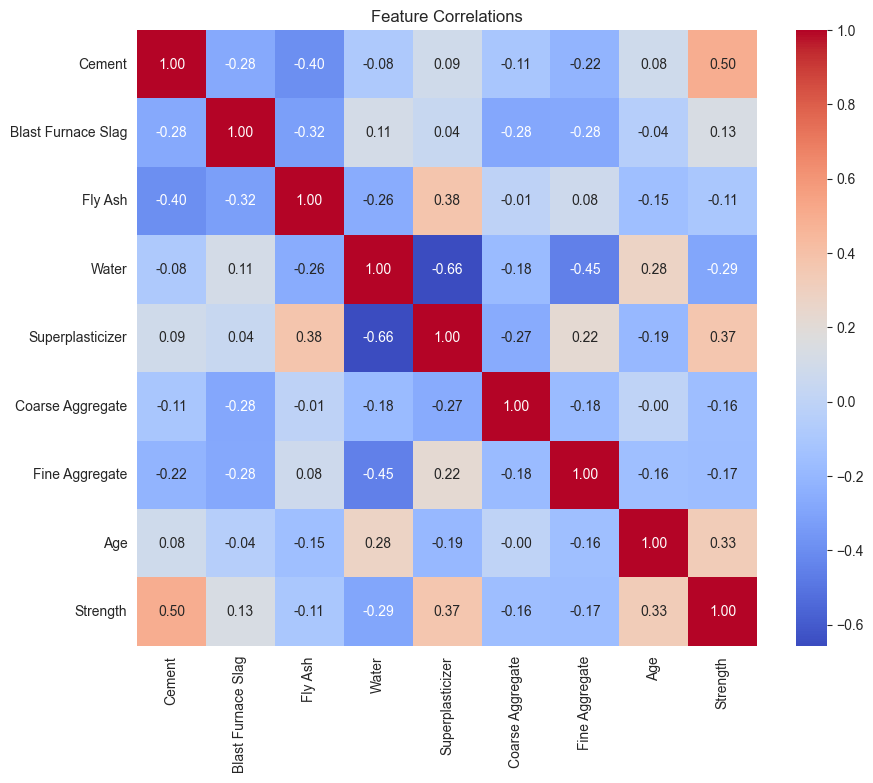

In [8]:
# Compute correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlations")
plt.show()


### **3.3️ Outlier Detection**
Outliers of the features is calculated. 


In [9]:
# Detecting potential outliers using the IQR method
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).sum()
print("Potential Outliers per Feature:")
print(outliers)


Potential Outliers per Feature:
Cement                 0
Blast Furnace Slag     2
Fly Ash                0
Water                  9
Superplasticizer      10
Coarse Aggregate       0
Fine Aggregate         5
Age                   59
Strength               4
dtype: int64


## 3️.4 Key Insights from Exploring the Data

### 3.4.1️ Feature Distributions & Outliers
- Outliers detected in `Age`, `Water`, `Superplasticizer`, and `Strength`, which may require handling.  
- `Strength` follows a mostly normal distribution but has some extreme values.  
- Scaling may be needed for models like SVR and Polynomial Regression.  

### 3.4.2️ Correlation Analysis
- `Cement` shows the highest correlation with `Strength` (`0.5`).  
- `Superplasticizer`, `Age`, and `Water` also influence `Strength`.  
- Some features interact strongly, which may affect model performance.  

### 3.4.3️ Next Steps
- Address outliers where necessary.  
- Manage high correlations if they impact predictions.  
- Apply feature scaling where needed.  
- Check for redundant features before modeling.  

## 4️ Prepare the data
To improve model performance, the dataset is cleaned and transformed. The following steps are automated:
- Handling outliers using the **Interquartile Range (IQR) method**.
- Removing **highly correlated features** to reduce redundancy.
- Scaling numerical features for models that require it.
- Ensuring data consistency by handling missing values and duplicates.

In [10]:
from sklearn.preprocessing import StandardScaler

### **4.1 Handling Outliers**
Outliers in `Age`, `Water`, `Superplasticizer`, and `Strength` are detected and managed using the **IQR method**.


In [11]:
# Function to replace outliers with the mean
def replace_outliers_with_mean(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    column = column.copy()
    column[(column < lower_bound) | (column > upper_bound)] = column.mean()
    return column

# Apply outlier handling to selected columns
outlier_columns = ['Age', 'Water', 'Superplasticizer', 'Strength']
df[outlier_columns] = df[outlier_columns].apply(replace_outliers_with_mean)


/var/folders/yh/k881ccjj4qjb55qnwn5y8l4c0000gn/T/ipykernel_62156/3471027163.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '45.662135922330094' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  column[(column < lower_bound) | (column > upper_bound)] = column.mean()


### **4.2️ Removing Highly Correlated Features**
To prevent redundancy, features with strong correlation (`> 0.6`) are removed.

In [12]:
def remove_highly_correlated_features(df, threshold=0.6):
    """Removes features that are highly correlated with others."""
    corr_matrix = df.corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return df.drop(columns=to_drop, errors="ignore"), to_drop

# Apply function
df, removed_features = remove_highly_correlated_features(df)
print(f"Removed features due to high correlation: {removed_features}")

Removed features due to high correlation: ['Superplasticizer']


### **4️.3 Ensuring Data Consistency**
- No missing values were detected in the original dataset.
- Duplicate rows are removed if found.


In [13]:
def clean_dataset(df):
    """Removes duplicates and fills missing values (if needed)."""
    df = df.drop_duplicates()
    df = df.fillna(df.mean())  # Replace missing values with column means
    return df

# Apply function
df_cleaned = clean_dataset(df)

### **4.4 Scaling Numerical Features**
Standardization is applied to ensure models like **SVR and Polynomial Regression** perform optimally.


In [14]:
def scale_features(X_train, X_test):
    """Standardizes training and test sets separately using StandardScaler."""
    scaler = StandardScaler()
    
    # Fit on training data, then transform both
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, scaler

# Apply function
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)


### **4.5 Next Steps**
- The dataset is now cleaned and scaled for model training.
- Features that were highly correlated are removed.
- Outliers have been handled using **IQR replacement**.
- The processed dataset will be used for model training and evaluation.

## 5️ Machine Learning Models

To determine the best approach for predicting concrete strength, a mix of **linear and non-linear models** will be tested.  
Each model will be trained, and its performance will be evaluated using key metrics defined in **step 1**.
By testing these models, a balance between accuracy, interpretability, and computational efficiency can be achieved.

### **5.1️ Linear Regression (Baseline)**
Linear Regression assumes a **direct linear relationship** between input features and the target.  
It serves as a **benchmark** for comparison.



In [15]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions
y_pred_lin = lin_reg.predict(X_test)

### **5.3️ Support Vector Regression (SVR)**
SVR is effective for **non-linear relationships**, using kernel functions like **Radial Basis Function (RBF)**.



In [16]:
from sklearn.svm import SVR

# Define and train SVR model with RBF kernel
svr_model = SVR(kernel="rbf", C=10, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svr = svr_model.predict(X_test_scaled)


### **5.4️ Random Forest Regressor**
A Random Forest model **combines multiple Decision Trees**, reducing overfitting and improving stability.



In [17]:
from sklearn.ensemble import RandomForestRegressor

# Define and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)


### **5.2️ Polynomial Regression**
If strong **non-linearity** is observed, Polynomial Regression is applied to introduce **higher-order terms**.



In [18]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Define and train polynomial regression model (degree 2)
poly_reg = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_reg.fit(X_train, y_train)

# Predictions
y_pred_poly = poly_reg.predict(X_test)


### **Models Not Included**
Some models were excluded due to overfitting risks or computational cost:
- **Decision Tree Regressor**: Prone to overfitting.
- **Stochastic Gradient Descent (SGD)**: Requires extensive tuning.
- **Polynomial Regression with Lasso**: Better suited for high-dimensional datasets.

By testing these models, a balance between **accuracy, interpretability, and efficiency** can be achieved.


## 6 Fine-Tuning the System

Hyperparameter tuning is applied to improve model performance.  
Each model is optimized using **Grid Search** or **Randomized Search**.

---
### **6.1️ Hyperparameter Tuning for SVR**
SVR is highly sensitive to hyperparameters like `C`, `gamma`, and `epsilon`.  
A **Grid Search** is used to find the best combination.


In [19]:
from sklearn.model_selection import GridSearchCV

In [20]:
# Define SVR parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.5, 1],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1]
}

svr_grid_search = GridSearchCV(SVR(kernel='rbf'), param_grid, cv=5, scoring='r2', n_jobs=-1)
svr_grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best parameters for SVR: {svr_grid_search.best_params_}")

Best parameters for SVR: {'C': 100, 'epsilon': 1, 'gamma': 'auto'}


### **6.2 Hyperparameter Tuning for Random Forest**
Random Forest has multiple parameters like `n_estimators`, `max_depth`, and `min_samples_split`.  
A **Randomized Search** is used for efficiency.


In [21]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

In [22]:
# Define Random Forest parameter grid
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Perform Randomized Search
rf_random_search = RandomizedSearchCV(RandomForestRegressor(), rf_param_grid, 
                                      n_iter=10, cv=5, scoring='r2', n_jobs=-1, random_state=42)
rf_random_search.fit(X_train, y_train)

# Best parameters
print(f"Best parameters for Random Forest: {rf_random_search.best_params_}")

Best parameters for Random Forest: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


### **3️.3 Hyperparameter Tuning for Polynomial Regression**
Polynomial Regression can overfit, so **Ridge regularization** is applied.  
A **Grid Search** is used to find the best degree and regularization strength.


In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

In [24]:
# Define Polynomial Regression parameter grid
poly_param_grid = {
    'polynomialfeatures__degree': [2, 3, 4],
    'ridge__alpha': np.logspace(-3, 3, 7)  # L2 regularization strength
}

# Create pipeline
poly_model = make_pipeline(PolynomialFeatures(), Ridge())

# Perform Grid Search
poly_grid_search = GridSearchCV(poly_model, poly_param_grid, cv=5, scoring='r2', n_jobs=-1)
poly_grid_search.fit(X_train_scaled, y_train)

# Best parameters
print(f"Best parameters for Polynomial Regression: {poly_grid_search.best_params_}")

Best parameters for Polynomial Regression: {'polynomialfeatures__degree': 3, 'ridge__alpha': np.float64(1.0)}


### **6.4 Selecting the Best Models**
The best-performing version of each model is stored for final evaluation.


In [25]:
# Store best models
best_svr = svr_grid_search.best_estimator_
best_rf = rf_random_search.best_estimator_
best_poly = poly_grid_search.best_estimator_

best_models = {
    "Linear Regression": lin_reg,
    "SVR": best_svr,
    "Random Forest": best_rf,
    "Polynomial Regression": best_poly
}


# 7️ Results & Model Comparison

This section evaluates the trained models and selects the best-performing approach based on **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **R² Score**.

## 7.1 Model Performance Overview
The table below summarizes the evaluation metrics for each model.


In [26]:
# Import required libraries
from IPython.display import display
from sklearn.metrics import mean_squared_error, r2_score

# Store evaluation metrics for models
results = {}

for model_name, model in best_models.items():
    y_pred = model.predict(X_test_scaled if model_name in ["SVR", "Polynomial Regression"] else X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[model_name] = [mse, rmse, r2]

# Convert results to DataFrame
results_df = pd.DataFrame(results, index=["MSE", "RMSE", "R²"]).T

# Display results
print("Model Performance Comparison:")
display(results_df)


Model Performance Comparison:


,MSE,RMSE,R²
Linear Regression,100.485111,10.024226,0.631094
SVR,25.150840,5.015061,0.907665
Random Forest,19.408944,4.405558,0.928745
Polynomial Regression,26.184940,5.117122,0.903868


## 7.2 Model Selection Insights

- The **best-performing model** is identified based on **the lowest MSE** and **highest R² Score**.
- **Bias-Variance Tradeoff Considerations**:
  - **Linear Regression** may underfit the data.
  - **SVR & Random Forest** may generalize better but require tuning.
- **Overfitting Check**:
  - If a model performs **significantly better on training data** than test data, **regularization** may be needed.


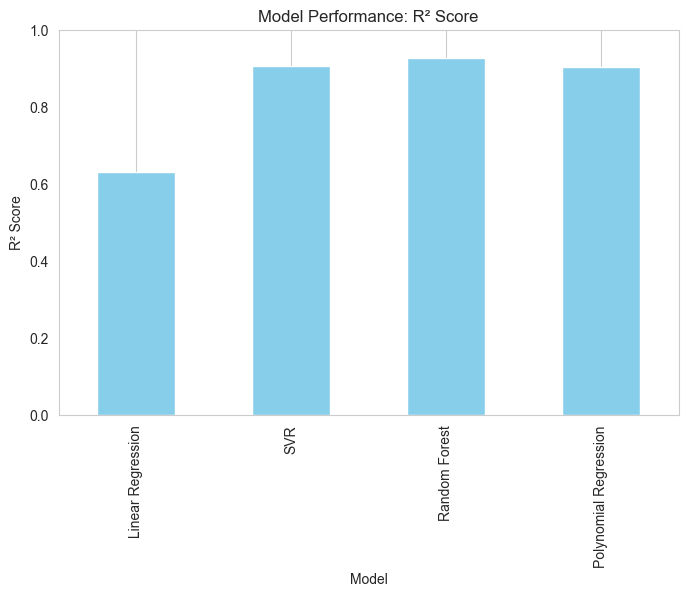

In [27]:
# Plot R² scores for each model
results_df["R²"].plot(kind="bar", color="skyblue", figsize=(8, 5))
plt.title("Model Performance: R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.grid(axis="y")
plt.show()

## 7.3 Training vs. Test Performance

To check for overfitting, we compare **training vs. test set performance**.


In [28]:
# Store evaluation metrics for training & test sets
performance_comparison = {}

for model_name, model in best_models.items():
    # Use scaled data where necessary
    X_train_input = X_train_scaled if model_name in ["SVR", "Polynomial Regression"] else X_train
    X_test_input = X_test_scaled if model_name in ["SVR", "Polynomial Regression"] else X_test

    # Predictions
    y_train_pred = model.predict(X_train_input)
    y_test_pred = model.predict(X_test_input)

    # Compute metrics
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    # Store results
    performance_comparison[model_name] = [train_mse, test_mse, train_r2, test_r2]

# Convert results to DataFrame
performance_df = pd.DataFrame(performance_comparison, index=["Train MSE", "Test MSE", "Train R²", "Test R²"]).T

# Display results
display(performance_df)

,Train MSE,Test MSE,Train R²,Test R²
Linear Regression,109.292957,100.485111,0.610241,0.631094
SVR,19.094256,25.150840,0.931906,0.907665
Random Forest,4.533506,19.408944,0.983833,0.928745
Polynomial Regression,22.424971,26.184940,0.920028,0.903868


### 7.4 Interpretation

- **If Train MSE ≈ Test MSE**, the model generalizes well.
- **If Train MSE << Test MSE**, the model **overfits** (memorizes training data, struggles with new data).
- **Higher R² on test set means better generalization.**


## 7.5 Scatter Plot of Actual vs. Predicted Values

To further analyze model accuracy, we plot **actual vs. predicted** values for all models.


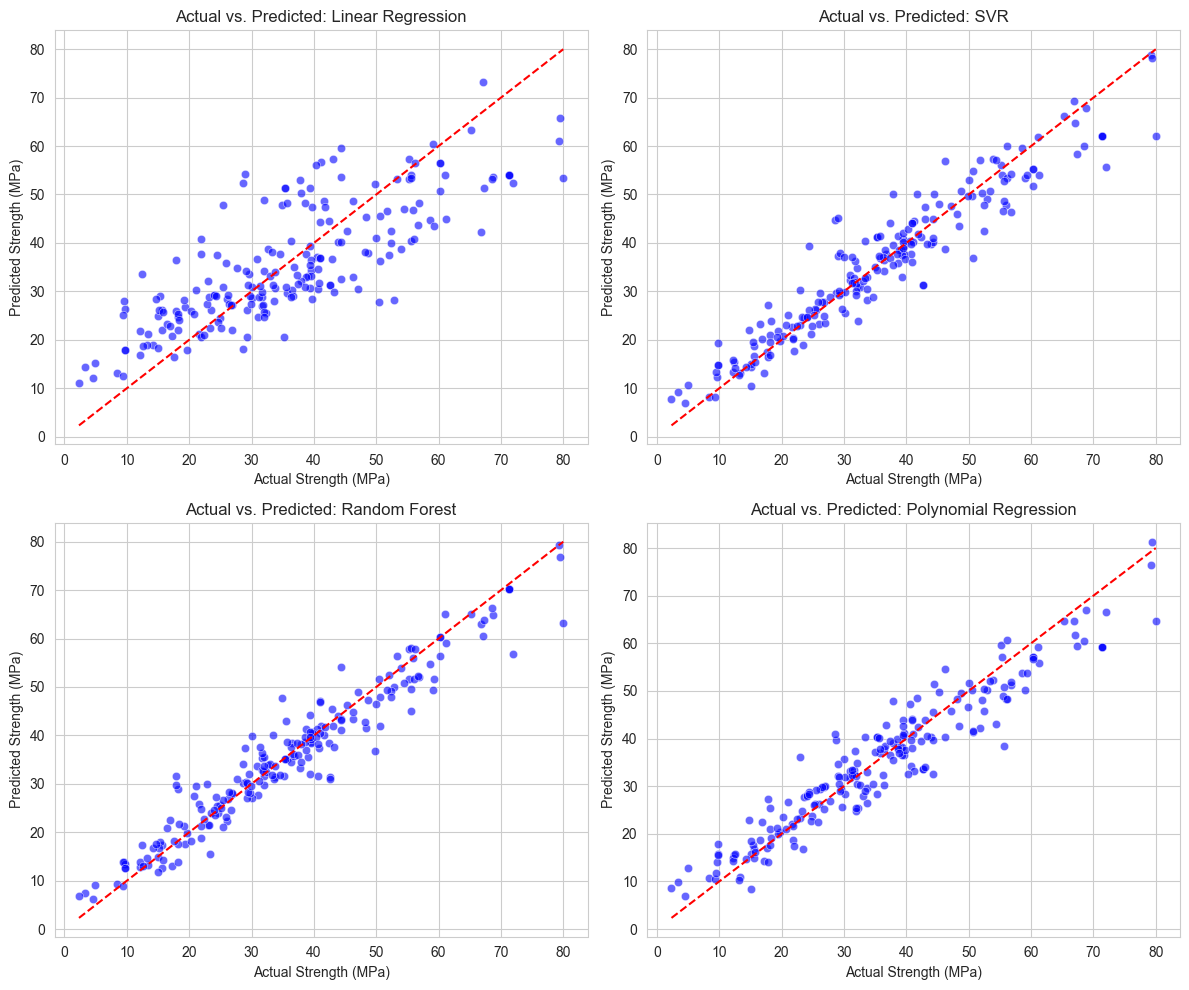

In [29]:
plt.figure(figsize=(12, 10))

for i, (model_name, model) in enumerate(best_models.items(), 1):
    # Use scaled data where necessary
    X_test_input = X_test_scaled if model_name in ["SVR", "Polynomial Regression"] else X_test
    
    # Predictions
    y_pred = model.predict(X_test_input)
    
    # Create subplot
    plt.subplot(2, 2, i)  # 2x2 grid for 4 models
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="blue")
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")  # Ideal line
    plt.title(f"Actual vs. Predicted: {model_name}")
    plt.xlabel("Actual Strength (MPa)")
    plt.ylabel("Predicted Strength (MPa)")
    plt.grid(True)

# Adjust layout and show plots
plt.tight_layout()
plt.show()

## 7.6 Conclusion

The final model selection is based on:
- **Performance (MSE, R²)**
- **Computational efficiency**


# 8️ Deployment & Model Monitoring

## 8.1️ Deployment Options
- **API Deployment**: Serve with **Flask/FastAPI** for real-time predictions.
- **Edge Computing**: Run locally for on-site use.
- **Cloud-Based**: Host on a **cloud server** and retrain periodically.

## 8.2️ Model Monitoring & Drift Detection
Check if the model's performance declines over time.


In [30]:
import numpy as np
from sklearn.metrics import mean_squared_error

def monitor_drift(model, X_recent, y_recent, past_mse):
    """Detects performance drift by comparing past vs. recent MSE."""
    y_pred_recent = model.predict(X_recent)
    recent_mse = mean_squared_error(y_recent, y_pred_recent)
    
    print(f"Past MSE: {past_mse:.2f}, Recent MSE: {recent_mse:.2f}")
    if recent_mse > past_mse * 1.1:
        print("⚠️ Performance decline detected. Consider retraining.")
    else:
        print("Model performance is stable.")

## 8.3️ Automated Retraining
Regularly update the model using fresh data.


In [31]:
def retrain_model(model, X_new, y_new):
    """Retrains model with new data."""
    model.fit(X_new, y_new)
    print("Model retrained.")
    return model

## 8.4️ Future Enhancements
- **More Data**: Improve generalization. **If overfitting is detected**, apply **regularization**.
- **New Models**: Test **Neural Networks**.
- **Optimization**: Use **model compression** for faster predictions.


# Conclusion

Based on the results, **Support Vector Regression (SVR)** shows strong performance in predicting concrete strength. While it may require **further tuning of hyperparameters**. 